In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [7]:
df = pd.read_csv("../data/processed/dataset.csv", dtype={"inoculum_cfu_ml": "string"})
df.head()

,record_id,peptide_sequence,peptide_name,organism_source,pathogen_name,pathogen_strain,measurement_value,measurement_unit,assay_method,medium,inoculum_cfu_ml,temperature_c,incubation_time_h,source_id,source_type,publication_year,source_url,doi
0,rec_rp556_atcc_25922_ramata2023_001,RWCFKVCYKGICYKKCK,RP556,synthetic,Escherichia coli,ATCC 25922,4.0,ug/mL,broth microdilution,MHB,5e5,32.0,16.0,paper_ramata_stunda_2023,scientific_paper,2023.0,https://doi.org/10.3390/antibiotics12030551,10.3390/antibiotics12030551
1,rec_rp556_atcc_27853_ramata2023_002,RWCFKVCYKGICYKKCK,RP556,synthetic,Pseudomonas aeruginosa,ATCC 27853,2.0,ug/mL,broth microdilution,MHB,5e5,32.0,16.0,paper_ramata_stunda_2023,scientific_paper,2023.0,https://doi.org/10.3390/antibiotics12030551,10.3390/antibiotics12030551
2,rec_rp556_atcc_70060_ramata2023_003,RWCFKVCYKGICYKKCK,RP556,synthetic,Klebsiella pneumoniae,ATCC 700603,4.0,ug/mL,broth microdilution,MHB,5e5,32.0,16.0,paper_ramata_stunda_2023,scientific_paper,2023.0,https://doi.org/10.3390/antibiotics12030551,10.3390/antibiotics12030551
3,rec_rp556_atcc_19434_ramata2023_004,RWCFKVCYKGICYKKCK,RP556,synthetic,Enterococcus faecium,ATCC 19434,2.0,ug/mL,broth microdilution,MHB,5e5,32.0,16.0,paper_ramata_stunda_2023,scientific_paper,2023.0,https://doi.org/10.3390/antibiotics12030551,10.3390/antibiotics12030551
4,rec_rp556_atcc_25923_ramata2023_005,RWCFKVCYKGICYKKCK,RP556,synthetic,Staphylococcus aureus,ATCC 25923,1.0,ug/mL,broth microdilution,MHB,5e5,32.0,16.0,paper_ramata_stunda_2023,scientific_paper,2023.0,https://doi.org/10.3390/antibiotics12030551,10.3390/antibiotics12030551


In [8]:
df.shape

(2406, 18)

In [16]:
df['measurement_value'] = pd.to_numeric(df['measurement_value'], errors='coerce')

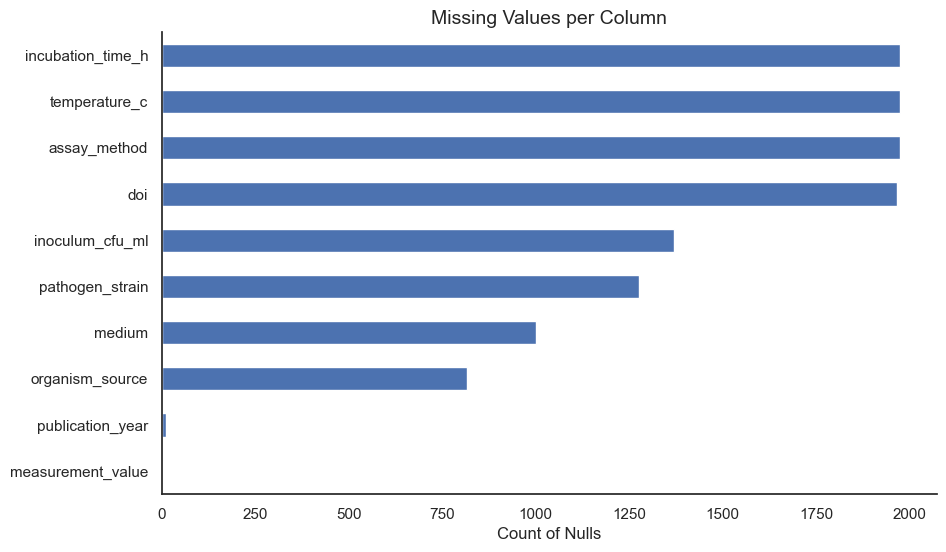

In [ ]:
plt.figure()
missing = df.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    missing.sort_values().plot(kind='barh', color='#4C72B0')
    plt.title('Missing Values per Column', fontsize=14)
    plt.xlabel('Count of Nulls')
    sns.despine()
    plt.show()

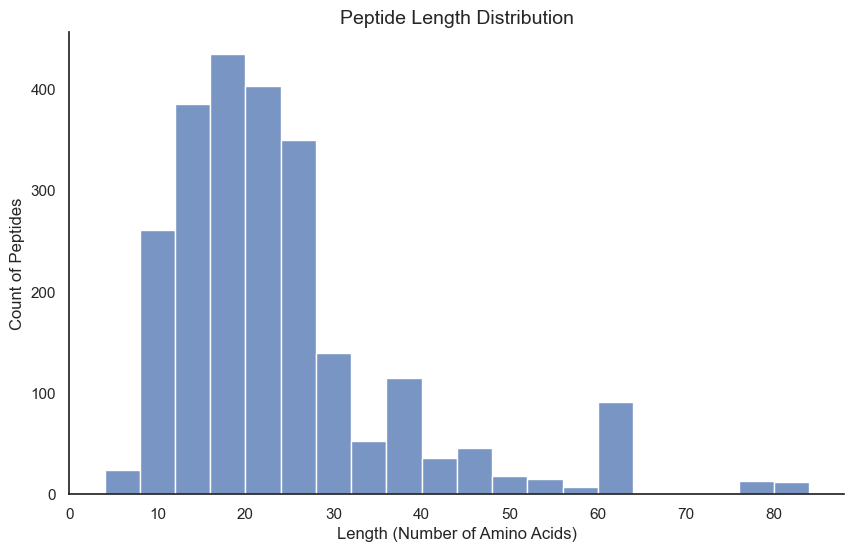

In [20]:
df['peptide_length'] = df['peptide_sequence'].str.len()

plt.figure()
sns.histplot(df['peptide_length'].dropna(), bins=20, color='#4C72B0', kde=False)
plt.title('Peptide Length Distribution', fontsize=14)
plt.xlabel('Length (Number of Amino Acids)')
plt.ylabel('Count of Peptides')
sns.despine()
plt.show()

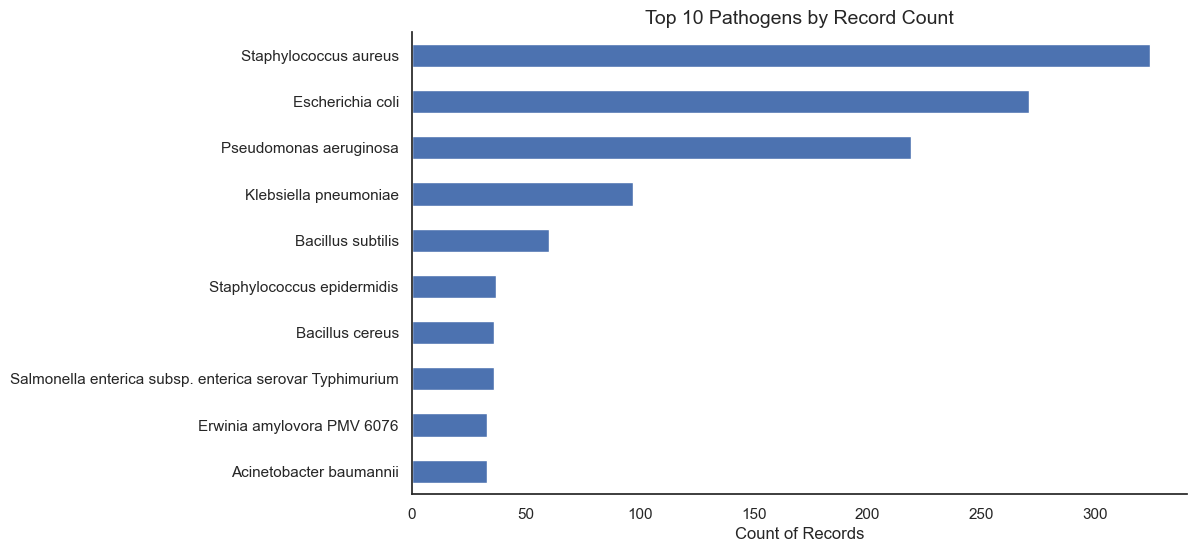

In [21]:
plt.figure()
df['pathogen_name'].value_counts().nlargest(10).sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 10 Pathogens by Record Count', fontsize=14)
plt.xlabel('Count of Records')
plt.ylabel('')
sns.despine()
plt.show()

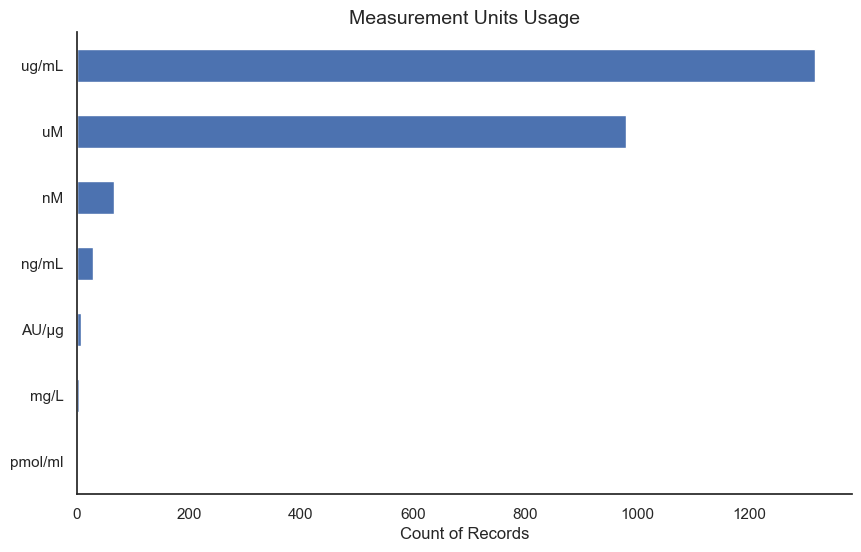

In [22]:
plt.figure()
df['measurement_unit'].value_counts().sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Measurement Units Usage', fontsize=14)
plt.xlabel('Count of Records')
plt.ylabel('')
sns.despine()
plt.show()

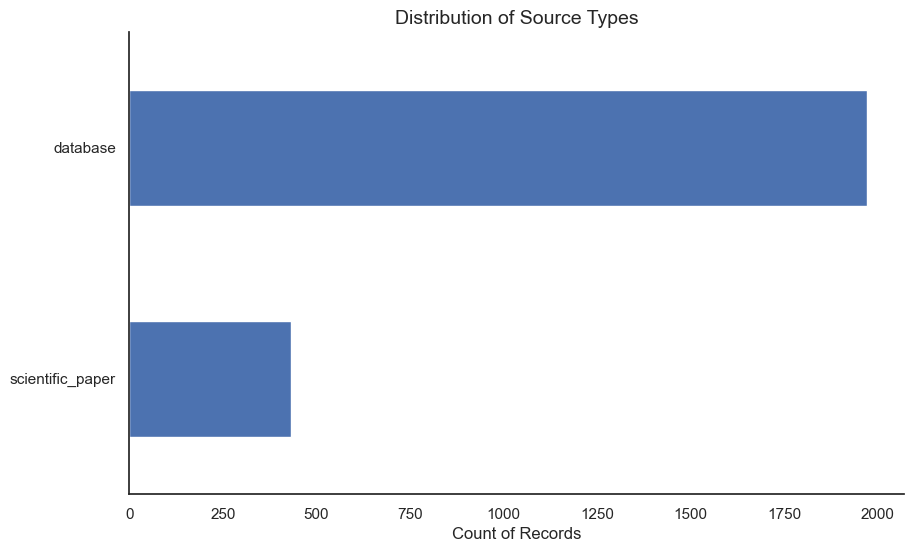

In [23]:
plt.figure()
df['source_type'].value_counts().sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Distribution of Source Types', fontsize=14)
plt.xlabel('Count of Records')
plt.ylabel('')
sns.despine()
plt.show()